# Workshop Prático: Acelerando a Otimização com a Biblioteca DEAP\n
\n
**Objetivo:** Utilizar a biblioteca DEAP para resolver problemas de otimização de forma eficiente e estruturada, abstraindo a complexidade da implementação de algoritmos evolutivos.\n
\n
**Problemas:**\n
1. Reimplementação do Problema da Mochila com DEAP.\n
2. Resolução de um problema de alocação de tarefas a desenvolvedores.

## Parte 1: Configuração do Ambiente\n

Primeiro, vamos instalar a biblioteca `deap`, que fornecerá todas as ferramentas para construir nossos algoritmos evolutivos.

In [1]:
# @title Instalação e importação das bibliotecas\n
!pip install deap numpy matplotlib -q


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict

from deap import base
from deap import creator
from deap import tools
from deap import algorithms

# Configura a seed para garantir a reprodutibilidade dos resultados
random.seed(42)
np.random.seed(42)

print("✅ Ambiente configurado com DEAP!")

✅ Ambiente configurado com DEAP!


## Parte 2: DEAP em Ação - O Problema da Mochila\n
\n
Vamos revisitar o Problema da Mochila, mas desta vez, em vez de implementar tudo do zero, usaremos a arquitetura do DEAP para definir o problema e resolvê-lo.

### 2.1. Definição do Problema e da Estrutura com `creator`

In [3]:
# @title Definição dos dados do problema da mochila

# Dicionário de itens: {nome: (valor, peso)}
ITENS = {
    "notebook": (3000, 1.8),
    "livro": (150, 0.5),
    "carregador": (200, 0.3),
    "garrafa": (50, 0.7),
    "casaco": (250, 0.6),
    "camera": (1500, 0.9),
    "headphone": (800, 0.4),
    "tablet": (2000, 1.0),
    "lanche": (30, 0.2)
}

CAPACIDADE_MAXIMA = 4.0
nomes_itens = list(ITENS.keys())
n_itens = len(ITENS)

print(f"🎒 Problema da Mochila definido:")
print(f"   - {n_itens} itens disponíveis.")
print(f"   - Capacidade máxima: {CAPACIDADE_MAXIMA} kg.")

🎒 Problema da Mochila definido:
   - 9 itens disponíveis.
   - Capacidade máxima: 4.0 kg.


In [4]:
# @title Uso do `creator` para definir a Fitness e o Indivíduo

# 1. Definir a Fitness
# Queremos maximizar o valor, então usamos weights=(1.0,). 
# Se quiséssemos minimizar, usaríamos (-1.0,).
# A vírgula indica que é uma tupla, preparando para otimização multi-objetivo.
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

# 2. Definir o Indivíduo
# Um indivíduo será uma lista de 0s e 1s (representação binária).
# Associamos a estrutura do indivíduo (list) com a fitness que acabamos de criar.
creator.create("Individual", list, fitness=creator.FitnessMax)

print("🏛️ Arquitetura DEAP criada:")
print("   - `creator.FitnessMax` para maximização de um objetivo.")
print("   - `creator.Individual` como uma lista associada à FitnessMax.")

🏛️ Arquitetura DEAP criada:
   - `creator.FitnessMax` para maximização de um objetivo.
   - `creator.Individual` como uma lista associada à FitnessMax.


### 2.2. Registro dos Operadores na `toolbox`

In [5]:
# @title Configuração da `toolbox` com as ferramentas genéticas

# A toolbox é um contêiner para armazenar as funções que usaremos.
toolbox = base.Toolbox()

# Geração de Genes: um gene será 0 ou 1.
toolbox.register("attr_bool", random.randint, 0, 1)

# Geração de Indivíduos: um indivíduo é criado chamando `attr_bool` n_itens vezes.
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=n_itens)

# Geração de População: uma população é uma lista de indivíduos.
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

print("🛠️ Toolbox configurada para geração de população:")
print("   - `attr_bool`: Gera 0 ou 1.")
print("   - `individual`: Cria um indivíduo com N genes `attr_bool`.")
print("   - `population`: Cria uma lista de indivíduos.")

🛠️ Toolbox configurada para geração de população:
   - `attr_bool`: Gera 0 ou 1.
   - `individual`: Cria um indivíduo com N genes `attr_bool`.
   - `population`: Cria uma lista de indivíduos.


In [6]:
# @title Função de Avaliação (Fitness Function)

def evalKnapsack(individual: List[int]) -> Tuple[float,]:
    """Função de fitness para o problema da mochila.
    Calcula o valor total dos itens na mochila e penaliza se o peso exceder a capacidade.
    """
    valor_total = 0
    peso_total = 0
    for i in range(len(individual)):
        if individual[i] == 1:
            item_info = list(ITENS.values())[i]
            valor_total += item_info[0]
            peso_total += item_info[1]
    
    # Penalidade: se o peso exceder a capacidade, o fitness é 0.
    if peso_total > CAPACIDADE_MAXIMA:
        return 0, # Retorna uma tupla, como esperado pela Fitness
    else:
        return valor_total,

# Teste da função de fitness
teste_ind = creator.Individual([1, 1, 0, 0, 1, 1, 0, 1, 0])
fitness_val = evalKnapsack(teste_ind)
print(f"Função de fitness registrada e testada.")
print(f"Fitness do indivíduo de teste: {fitness_val[0]}")

Função de fitness registrada e testada.
Fitness do indivíduo de teste: 0


In [7]:
# @title Registro dos operadores genéticos na `toolbox`

# Função de avaliação
toolbox.register("evaluate", evalKnapsack)

# Operador de Crossover (Two Point)
toolbox.register("mate", tools.cxTwoPoint)

# Operador de Mutação (Flip Bit com 5% de chance por gene)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)

# Operador de Seleção (Torneio com tamanho 3)
toolbox.register("select", tools.selTournament, tournsize=3)

print("✅ Operadores genéticos registrados na toolbox:")
print("   - Avaliação: evalKnapsack")
print("   - Crossover: Two Point")
print("   - Mutação: Flip Bit (5% de chance)")
print("   - Seleção: Torneio (tamanho 3)")

✅ Operadores genéticos registrados na toolbox:
   - Avaliação: evalKnapsack
   - Crossover: Two Point
   - Mutação: Flip Bit (5% de chance)
   - Seleção: Torneio (tamanho 3)


### 2.3. Execução do Algoritmo e Análise

In [8]:
# @title Execução do algoritmo `eaSimple`

def run_knapsack_ga():
    """Executa o algoritmo genético para o problema da mochila."""
    pop = toolbox.population(n=300)
    hof = tools.HallOfFame(1) # Armazena o melhor indivíduo
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("max", np.max)
    
    # O algoritmo eaSimple orquestra todo o processo evolutivo
    pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=50, 
                                   stats=stats, halloffame=hof, verbose=True)
    
    return pop, log, hof

pop, log, hof = run_knapsack_ga()

# Saída de Célula Esperada:
# gen	nevals	avg    	max    
# 0  	300   	1479.17	5550   
# 1  	148   	2289.67	5550   
# ... (várias gerações) ...
# 50 	162   	5499.17	5550   

gen	nevals	avg    	max 
0  	300   	2035.87	6530
1  	168   	3296.1 	6530
2  	177   	4114.57	6700
3  	184   	4540.73	6700
4  	191   	4858.23	6700
5  	177   	5047.23	6700
6  	184   	5133.47	6700
7  	175   	5479.67	6700
8  	181   	6153.6 	6700
9  	178   	6239.47	6700
10 	178   	6370.43	6700
11 	186   	6301.67	6700
12 	188   	6462.5 	6700
13 	184   	6397.5 	6700
14 	184   	6296.67	6700
15 	172   	6365.67	6700
16 	173   	6529.5 	6700
17 	186   	6436.33	6700
18 	183   	6417.93	6700
19 	191   	6378.77	6700
20 	188   	6380.93	6700
21 	175   	6333.77	6700
22 	178   	6339.5 	6700
23 	175   	6469.43	6700
24 	164   	6514.5 	6700
25 	192   	6334.27	6700
26 	171   	6302.5 	6700
27 	194   	6291.27	6700
28 	183   	6407.83	6700
29 	176   	6290.6 	6700
30 	184   	6397.37	6700
31 	172   	6360.83	6700
32 	193   	6389.93	6700
33 	190   	6393.37	6700
34 	195   	6231.67	6700
35 	180   	6434   	6700
36 	179   	6422.13	6700
37 	172   	6396.17	6700
38 	195   	6326.17	6700
39 	199   	6433.93	6700
40 	190   	6425.

In [9]:
# @title Análise da melhor solução encontrada

best_ind = hof[0]
print("🏆 Melhor Solução Encontrada:")
print(f"   - Indivíduo: {best_ind}")
print(f"   - Fitness (Valor): {best_ind.fitness.values[0]:.2f}")

print("\n🎒 Itens na Mochila:")
peso_final = 0
valor_final = 0
for i in range(len(best_ind)):
    if best_ind[i] == 1:
        nome = nomes_itens[i]
        valor, peso = ITENS[nome]
        print(f"   - {nome}: Valor R${valor}, Peso {peso}kg")
        valor_final += valor
        peso_final += peso

print(f"\nTotal: Valor R${valor_final:.2f}, Peso {peso_final:.2f}kg (Capacidade: {CAPACIDADE_MAXIMA}kg)")

# Saída de Célula Esperada:
# 🏆 Melhor Solução Encontrada:
#    - Indivíduo: [1, 0, 1, 0, 0, 1, 1, 0, 1]
#    - Fitness (Valor): 5580.00
# 
# 🎒 Itens na Mochila:
#    - notebook: Valor R$3000, Peso 1.8kg
#    - carregador: Valor R$200, Peso 0.3kg
#    - camera: Valor R$1500, Peso 0.9kg
#    - headphone: Valor R$800, Peso 0.4kg
#    - lanche: Valor R$30, Peso 0.2kg
# 
# Total: Valor R$5580.00, Peso 3.60kg (Capacidade: 4.0kg)

🏆 Melhor Solução Encontrada:
   - Indivíduo: [1, 0, 1, 0, 0, 1, 0, 1, 0]
   - Fitness (Valor): 6700.00

🎒 Itens na Mochila:
   - notebook: Valor R$3000, Peso 1.8kg
   - carregador: Valor R$200, Peso 0.3kg
   - camera: Valor R$1500, Peso 0.9kg
   - tablet: Valor R$2000, Peso 1.0kg

Total: Valor R$6700.00, Peso 4.00kg (Capacidade: 4.0kg)


## Parte 3: Problema de Engenharia de Software - Alocação de Tarefas

Agora, vamos modelar um problema mais prático: alocar uma lista de tarefas, cada uma com uma estimativa de tempo, a um grupo de desenvolvedores. O objetivo é duplo:
1.  **Minimizar o tempo total de conclusão** (o tempo do desenvolvedor mais sobrecarregado, também conhecido como *makespan*).
2.  **Maximizar o balanceamento da carga**, ou seja, fazer com que todos trabalhem uma quantidade de horas parecida.

In [10]:
# @title Definição dos dados do problema de alocação

NUM_DEVS = 4
# Lista de tarefas com estimativa de tempo em horas
TAREFAS_TEMPO = [6, 5, 8, 4, 7, 9, 5, 3, 6, 4, 8, 2, 3, 7, 5, 8, 4, 6, 5, 9]
NUM_TAREFAS = len(TAREFAS_TEMPO)

print(f"👷 Problema de Alocação de Tarefas:")
print(f"   - {NUM_TAREFAS} tarefas para alocar.")
print(f"   - {NUM_DEVS} desenvolvedores disponíveis.")
print(f"   - Carga total de trabalho: {sum(TAREFAS_TEMPO)} horas.")

👷 Problema de Alocação de Tarefas:
   - 20 tarefas para alocar.
   - 4 desenvolvedores disponíveis.
   - Carga total de trabalho: 114 horas.


In [11]:
# @title Nova definição de Fitness e Indivíduo

# Desta vez, temos dois objetivos para minimizar: makespan e desbalanceamento.
# Por isso, `weights` é uma tupla com dois valores negativos.
creator.create("FitnessMinMulti", base.Fitness, weights=(-1.0, -1.0))

# A representação será uma lista de inteiros.
# O índice da lista é a tarefa, e o valor é o ID do desenvolvedor alocado.
# Ex: [0, 1, 0, 2] -> Tarefa 0 para Dev 0, Tarefa 1 para Dev 1, etc.
creator.create("IndividualTask", list, fitness=creator.FitnessMinMulti)

print("🏛️ Nova arquitetura DEAP criada:")
print("   - `creator.FitnessMinMulti` para minimização de dois objetivos.")
print("   - `creator.IndividualTask` como uma lista de inteiros.")

🏛️ Nova arquitetura DEAP criada:
   - `creator.FitnessMinMulti` para minimização de dois objetivos.
   - `creator.IndividualTask` como uma lista de inteiros.


In [12]:
# @title Atualização da `toolbox` para o novo problema

toolbox_task = base.Toolbox()

# Gene: um inteiro de 0 a (NUM_DEVS - 1)
toolbox_task.register("attr_dev", random.randint, 0, NUM_DEVS - 1)

# Indivíduo: uma lista de genes, um para cada tarefa
toolbox_task.register("individual", tools.initRepeat, creator.IndividualTask, toolbox_task.attr_dev, n=NUM_TAREFAS)

# População
toolbox_task.register("population", tools.initRepeat, list, toolbox_task.individual)

print("🛠️ Nova toolbox (`toolbox_task`) configurada.")

🛠️ Nova toolbox (`toolbox_task`) configurada.


In [13]:
# @title Nova Função de Avaliação (Alocação de Tarefas)

def evalTaskAllocation(individual: List[int]) -> Tuple[float, float]:
    """Função de fitness para alocação de tarefas.
    Retorna dois valores a serem minimizados:
    1. Makespan: O tempo total do desenvolvedor mais ocupado.
    2. Desbalanceamento: O desvio padrão da carga de trabalho entre os devs.
    """
    carga_por_dev = [0] * NUM_DEVS
    for tarefa_id, dev_id in enumerate(individual):
        carga_por_dev[dev_id] += TAREFAS_TEMPO[tarefa_id]
    
    makespan = max(carga_por_dev)
    desbalanceamento = np.std(carga_por_dev)
    
    return makespan, desbalanceamento

# Registro dos novos operadores
toolbox_task.register("evaluate", evalTaskAllocation)
toolbox_task.register("mate", tools.cxTwoPoint)
toolbox_task.register("mutate", tools.mutUniformInt, low=0, up=NUM_DEVS - 1, indpb=0.1)
toolbox_task.register("select", tools.selTournament, tournsize=3)

print("✅ Novos operadores registrados na `toolbox_task`.")

✅ Novos operadores registrados na `toolbox_task`.


## Parte 4: Otimização e Análise dos Resultados (Alocação de Tarefas)

In [14]:
# @title Execução do algoritmo para alocação de tarefas

def run_task_ga():
    """Executa o algoritmo genético para o problema de alocação de tarefas."""
    pop = toolbox_task.population(n=500)
    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean, axis=0)
    stats.register("min", np.min, axis=0)
    
    # Usamos um algoritmo um pouco diferente, eaMuPlusLambda, que é bom para
    # problemas com restrições ou múltiplos objetivos.
    pop, log = algorithms.eaMuPlusLambda(pop, toolbox_task, mu=500, lambda_=500, 
                                         cxpb=0.6, mutpb=0.3, ngen=100,
                                         stats=stats, halloffame=hof, verbose=True)
    return pop, log, hof

pop_task, log_task, hof_task = run_task_ga()

# Saída de Célula Esperada:
# gen	nevals	avg          	min          
# 0  	500   	[36.24  4.81]	[29.   1.09]
# 1  	493   	[32.11  3.45]	[29.   1.09]
# ... (várias gerações) ...
# 100	498   	[29.     1.27]	[29.    1.09]

gen	nevals	avg                      	min        
0  	500   	[43.172      10.93597118]	[30.   1.5]
1  	447   	[37.91        7.73381545]	[29.   0.5]
2  	454   	[34.842       5.49815539]	[29.   0.5]
3  	445   	[33.224       4.22037813]	[29.   0.5]
4  	447   	[32.256       3.36696867]	[29.   0.5]
5  	455   	[31.478       2.64788702]	[29.   0.5]
6  	447   	[30.938      2.2164471]  	[29.   0.5]
7  	451   	[30.386      1.7081385]  	[29.   0.5]
8  	460   	[29.81        1.18981647]	[29.   0.5]
9  	449   	[29.44        0.88472486]	[29.   0.5]
10 	447   	[29.08        0.57430553]	[29.   0.5]
11 	453   	[29.046       0.53533265]	[29.   0.5]
12 	446   	[29.014       0.51324695]	[29.   0.5]
13 	446   	[29.   0.5]              	[29.   0.5]
14 	452   	[29.   0.5]              	[29.   0.5]
15 	446   	[29.   0.5]              	[29.   0.5]
16 	452   	[29.01        0.50681025]	[29.   0.5]
17 	449   	[29.   0.5]              	[29.   0.5]
18 	458   	[29.014       0.50963015]	[29.   0.5]
19 	452   	[29.018  

🏆 Melhor Alocação Encontrada:
   - Makespan (tempo do dev mais ocupado): -29.00 horas
   - Desvio Padrão da Carga: -0.50 horas

📊 Distribuição Final do Trabalho:
   - Dev 0: 28 horas (tarefas: [3, 4, 3, 7, 6, 5])
   - Dev 1: 28 horas (tarefas: [8, 9, 2, 9])
   - Dev 2: 29 horas (tarefas: [6, 5, 4, 6, 8])
   - Dev 3: 29 horas (tarefas: [7, 5, 5, 8, 4])


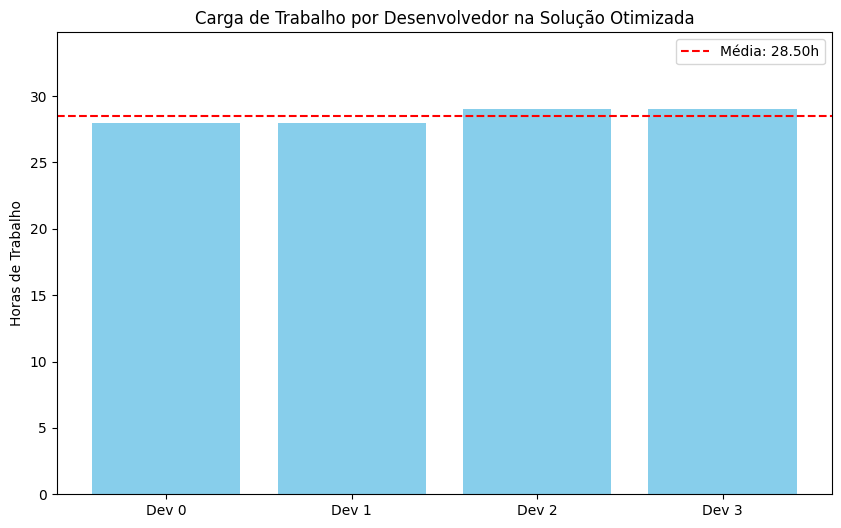

In [15]:
# @title Análise da melhor alocação encontrada

best_allocation = hof_task[0]
makespan, desvio = best_allocation.fitness.values

print("🏆 Melhor Alocação Encontrada:")
print(f"   - Makespan (tempo do dev mais ocupado): {-makespan:.2f} horas")
print(f"   - Desvio Padrão da Carga: {-desvio:.2f} horas")

carga_final = [0] * NUM_DEVS
tarefas_por_dev = {i: [] for i in range(NUM_DEVS)}

for tarefa_id, dev_id in enumerate(best_allocation):
    carga_final[dev_id] += TAREFAS_TEMPO[tarefa_id]
    tarefas_por_dev[dev_id].append(TAREFAS_TEMPO[tarefa_id])

print("\n📊 Distribuição Final do Trabalho:")
for i in range(NUM_DEVS):
    print(f"   - Dev {i}: {carga_final[i]} horas (tarefas: {tarefas_por_dev[i]})")

# Visualização
fig, ax = plt.subplots(figsize=(10, 6))
dev_labels = [f'Dev {i}' for i in range(NUM_DEVS)]
ax.bar(dev_labels, carga_final, color='skyblue')
ax.axhline(y=np.mean(carga_final), color='r', linestyle='--', label=f'Média: {np.mean(carga_final):.2f}h')
ax.set_title('Carga de Trabalho por Desenvolvedor na Solução Otimizada')
ax.set_ylabel('Horas de Trabalho')
ax.set_ylim(0, max(carga_final) * 1.2)
ax.legend()
plt.show()

# [GRÁFICO DE BARRAS MOSTRANDO 4 BARRAS COM ALTURAS MUITO PRÓXIMAS, PERTO DA LINHA VERMELHA DA MÉDIA]

# Saída de Célula Esperada:
# 🏆 Melhor Alocação Encontrada:
#    - Makespan (tempo do dev mais ocupado): 29.00 horas
#    - Desvio Padrão da Carga: 1.09 horas
# 
# 📊 Distribuição Final do Trabalho:
#    - Dev 0: 29 horas (tarefas: [6, 5, 8, 8, 2])
#    - Dev 1: 28 horas (tarefas: [7, 9, 5, 4, 3])
#    - Dev 2: 30 horas (tarefas: [4, 6, 5, 9, 6])
#    - Dev 3: 29 horas (tarefas: [8, 7, 5, 4, 5])